In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

print("✅ TensorFlow version:", tf.__version__)
print("✅ GPU Available:", tf.config.list_physical_devices('GPU'))


✅ TensorFlow version: 2.18.0
✅ GPU Available: []


2025-11-11 11:01:12.671506: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Normalize image pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode target labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [10]:
# Define a simple ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)),       # Input layer (784 features)
    Dense(128, activation='relu'),       # Hidden layer 1
    Dense(64, activation='relu'),        # Hidden layer 2
    Dense(10, activation='softmax')      # Output layer (10 classes)
])

# Display model structure
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile model with Adam optimizer and cross-entropy loss
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
# Train the ANN model
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)


Epoch 1/10
375/375 - 3s - 9ms/step - accuracy: 0.8929 - loss: 0.3868 - val_accuracy: 0.9478 - val_loss: 0.1817
Epoch 2/10
375/375 - 2s - 5ms/step - accuracy: 0.9532 - loss: 0.1580 - val_accuracy: 0.9618 - val_loss: 0.1361
Epoch 3/10
375/375 - 2s - 5ms/step - accuracy: 0.9679 - loss: 0.1101 - val_accuracy: 0.9653 - val_loss: 0.1139
Epoch 4/10
375/375 - 2s - 5ms/step - accuracy: 0.9753 - loss: 0.0835 - val_accuracy: 0.9674 - val_loss: 0.1106
Epoch 5/10
375/375 - 2s - 5ms/step - accuracy: 0.9800 - loss: 0.0661 - val_accuracy: 0.9676 - val_loss: 0.1122
Epoch 6/10
375/375 - 2s - 5ms/step - accuracy: 0.9844 - loss: 0.0535 - val_accuracy: 0.9708 - val_loss: 0.1008
Epoch 7/10
375/375 - 2s - 5ms/step - accuracy: 0.9865 - loss: 0.0435 - val_accuracy: 0.9733 - val_loss: 0.0935
Epoch 8/10
375/375 - 2s - 5ms/step - accuracy: 0.9901 - loss: 0.0341 - val_accuracy: 0.9741 - val_loss: 0.0951
Epoch 9/10
375/375 - 2s - 5ms/step - accuracy: 0.9921 - loss: 0.0275 - val_accuracy: 0.9732 - val_loss: 0.0954
E

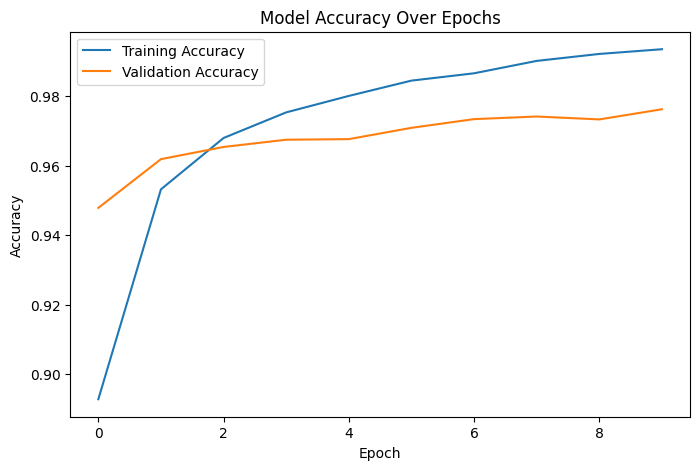

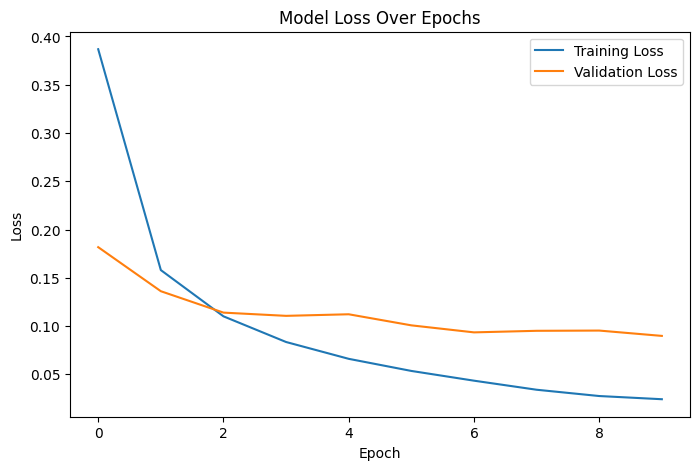

In [13]:
# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [14]:
# Evaluate on test dataset
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# Predict test set labels
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')

print("\n📊 Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")


313/313 - 1s - 2ms/step - accuracy: 0.9770 - loss: 0.0742

✅ Test Accuracy: 0.9770
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Evaluation Metrics:
Accuracy : 0.9770
Precision: 0.9771
Recall   : 0.9770


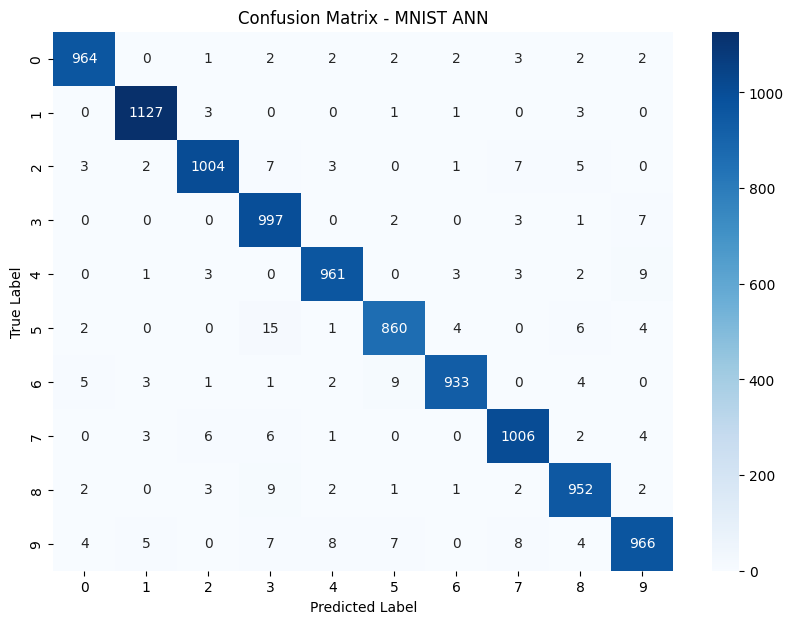


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.99      0.97      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

✅ Model saved as mnist_ann_model.h5


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - MNIST ANN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))
# Save the trained model for reuse
model.save("/kaggle/working/mnist_ann_model.h5")
print("✅ Model saved as mnist_ann_model.h5")

